# Comparative Analysis of Machine Learning Models for Heart Disease Prediction Using Clinical Data

**Student:** Godbless Keku  
**Course:** Intro ML, X400  

## Notebook goals
This notebook does four things in one place:

1. Loads the heart disease dataset from `artifacts/heart.csv`
2. Cleans, preprocesses, trains, tunes, and evaluates several ML models
3. Generates all figures needed for the final paper
4. Saves the best model with `joblib` and provides an in-notebook dashboard that **loads the saved model without retraining**


## 1. Problem Definition

### Scope and context
Heart disease is a major global health challenge. Timely prediction can help clinicians identify higher-risk patients earlier and support faster medical decision-making.

### Objective
Build and compare machine learning classification models that predict whether heart disease is present using structured clinical data. Evaluate the models using accuracy, precision, recall, F1-score, and ROC-AUC, then deploy the best model inside a simple in-notebook demonstration dashboard.

### Data identification
The project uses the standard heart disease dataset with these expected columns:

`age, sex, cp, trestbps, chol, fbs, restecg, thalch, exang, oldpeak, slope, ca, thal, target`

### Stakeholders
- **Clinicians**, who need timely decision support
- **Hospitals**, which benefit from more efficient triage and assessment
- **Patients**, who benefit from earlier intervention
- **Researchers and students**, who need an interpretable ML workflow

In [4]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML, Markdown, clear_output
import ipywidgets as widgets

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Use matplotlib default style only
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [5]:
# Paths and artifact configuration
ROOT = Path(".")
ARTIFACT_DIR = ROOT / "artifacts"
DATA_PATH = ARTIFACT_DIR / "heart.csv"
MODEL_PATH = ARTIFACT_DIR / "heart_best_model.joblib"
METRICS_PATH = ARTIFACT_DIR / "heart_model_summary.json"
RESULTS_CSV_PATH = ARTIFACT_DIR / "heart_model_results.csv"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Artifact directory:", ARTIFACT_DIR.resolve())
print("Dataset path:", DATA_PATH.resolve())
print("Model path:", MODEL_PATH.resolve())
print("Metrics path:", METRICS_PATH.resolve())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. "
        "Place your downloaded dataset file in artifacts/heart.csv and rerun."
    )

Artifact directory: C:\Coding\Python\Ucsc\lab\ML\Project\ml_project\notebooks\artifacts
Dataset path: C:\Coding\Python\Ucsc\lab\ML\Project\ml_project\notebooks\artifacts\heart.csv
Model path: C:\Coding\Python\Ucsc\lab\ML\Project\ml_project\notebooks\artifacts\heart_best_model.joblib
Metrics path: C:\Coding\Python\Ucsc\lab\ML\Project\ml_project\notebooks\artifacts\heart_model_summary.json


## 2. Data Collection and Preparation



In [6]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

# Standardize column names, keeping the original dataset feature as `thalch`
df.columns = [c.strip().lower() for c in df.columns]

# Support some alternate target names if present
if "target" not in df.columns:
    for alt in ["num", "output", "label", "condition"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "target"})
            break

expected_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalch", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

missing_cols = [c for c in expected_columns if c not in df.columns]
if missing_cols:
    raise ValueError(
        "Your dataset is missing required columns: " + ", ".join(missing_cols)
    )

df = df[expected_columns].copy()
print("Using shape:", df.shape)
print("Columns:", df.columns.tolist())


Raw shape: (920, 16)
Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Using shape: (920, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [7]:
# Basic cleaning
df = df.drop_duplicates().copy()

# Standardize target
if df["target"].dtype == object:
    df["target"] = (
        df["target"]
        .astype(str)
        .str.lower()
        .isin(["1", "true", "yes", "disease", "present"])
    ).astype(int)

# Convert disease severity from any value > 0 to 1 for binary classification.
df["target"] = (pd.to_numeric(df["target"], errors="coerce").fillna(0) > 0).astype(int)

# Identify numeric and categorical feature columns based on the uploaded dataset schema.
numeric_features = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

# Convert only numeric feature columns to numeric values.
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Standardize categorical text spacing and casing without forcing numeric conversion.
for col in categorical_features:
    df[col] = df[col].astype(str).str.strip()

print("Numeric feature columns:", numeric_features)
print("Categorical feature columns:", categorical_features)

print("\nMissing values by column:")
display(df.isna().sum().to_frame("missing"))

print("\nTarget distribution:")
print(df["target"].value_counts())

df.head()


Numeric feature columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical feature columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Missing values by column:


,missing
age,0
sex,0
cp,0
trestbps,59
chol,29
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62



Target distribution:
target
1    508
0    410
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3. Exploratory Data Analysis and Figures


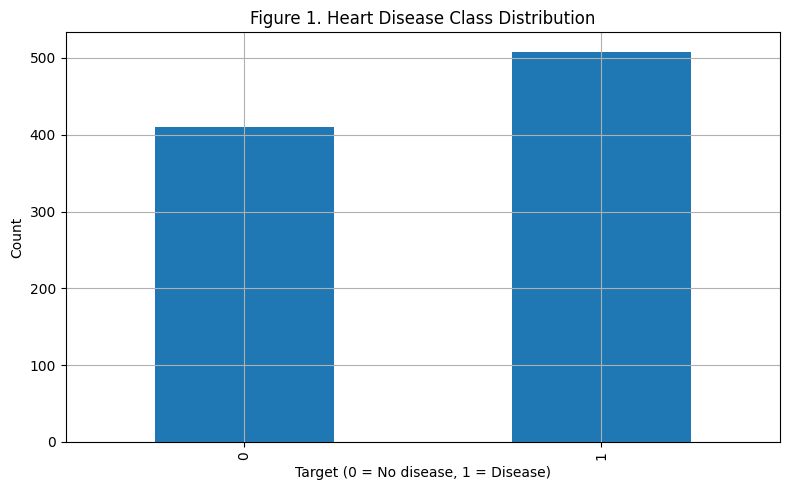

In [8]:
# Figure 1: Target distribution
fig = plt.figure()
df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Figure 1. Heart Disease Class Distribution")
plt.xlabel("Target (0 = No disease, 1 = Disease)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

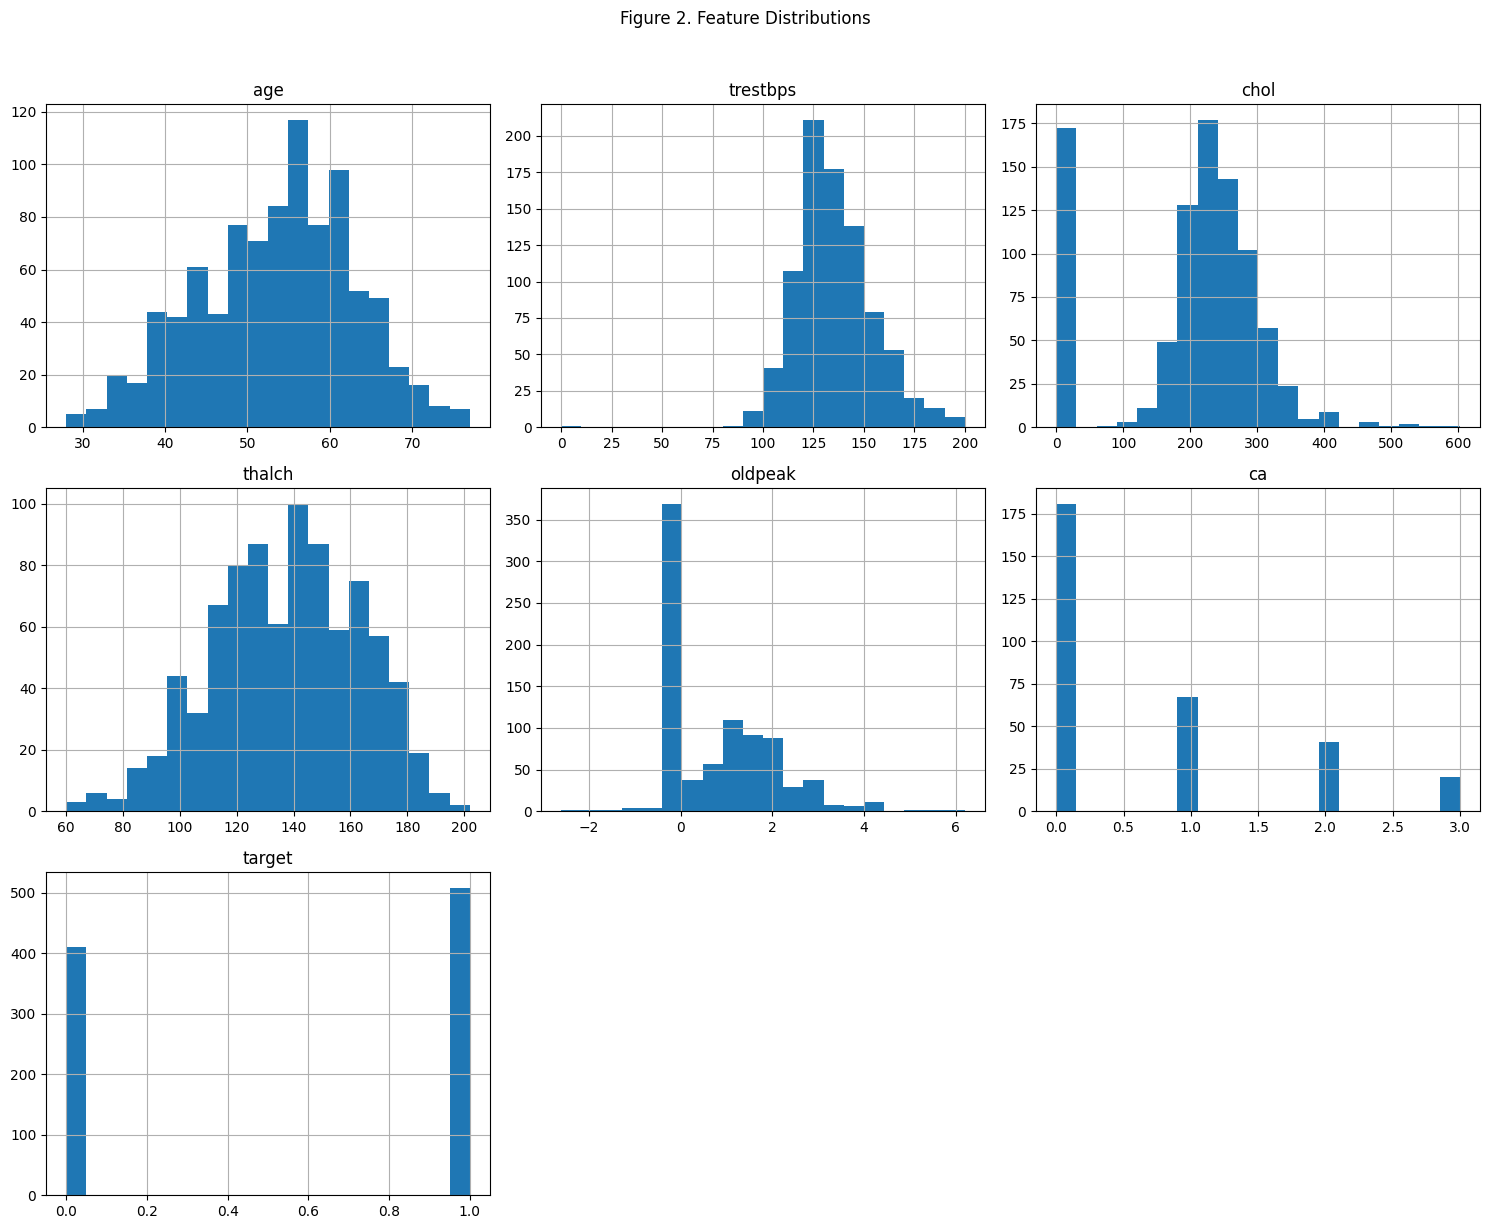

In [9]:
# Figure 2: Feature histograms
fig = df.hist(figsize=(15, 12), bins=20)
plt.suptitle("Figure 2. Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

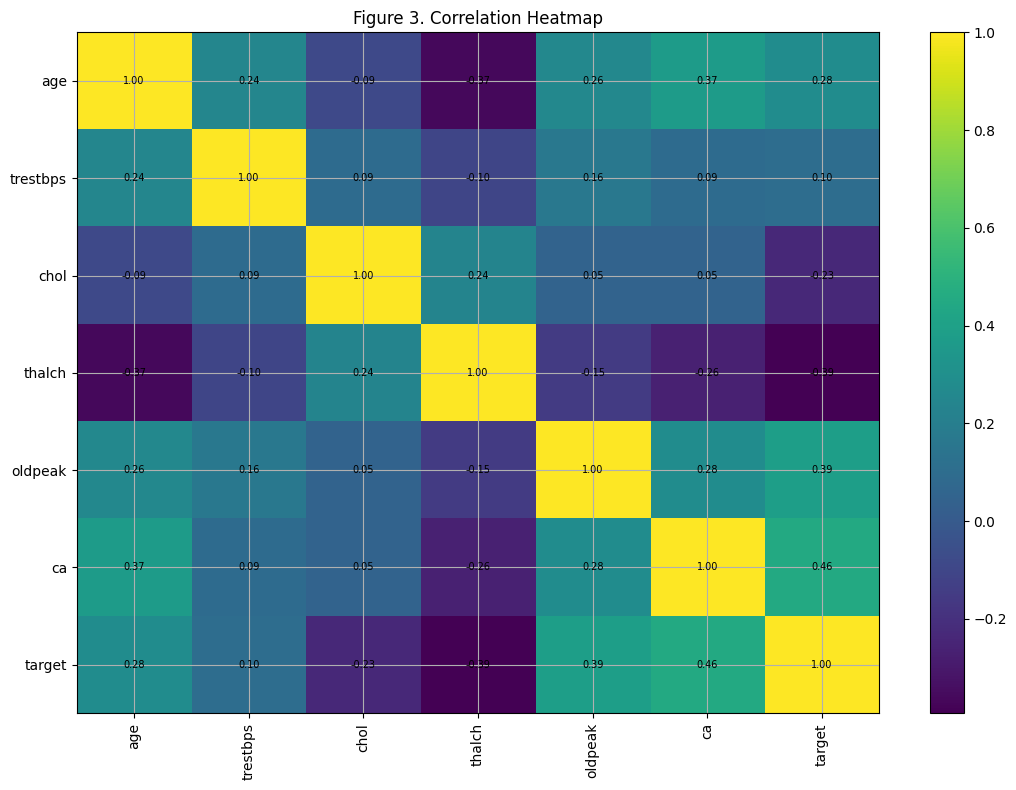

In [10]:
# Figure 3: Correlation heatmap without seaborn
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 8))
cax = ax.imshow(corr, interpolation="nearest", aspect="auto")
ax.set_title("Figure 3. Correlation Heatmap")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(cax)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Partitioning
The data is split into training, validation, and test sets.  

In [11]:

X = df.drop(columns=["target"]).copy()
y = df["target"].copy()

# Keep the explicit feature grouping so the preprocessing pipeline can
# scale numeric features and one-hot encode categorical features.
numeric_features = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)
print("\nCategorical features used in training:", categorical_features)
print("Numeric features used in training:", numeric_features)


Training set: (642, 13) (642,)
Validation set: (138, 13) (138,)
Test set: (138, 13) (138,)

Categorical features used in training: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numeric features used in training: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


In [12]:

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

display(Markdown(
    f"**Preprocessing setup**<br>"
    f"- Numeric features are median-imputed and standardized.<br>"
    f"- Categorical features are most-frequent imputed and one-hot encoded."
))


**Preprocessing setup**<br>- Numeric features are median-imputed and standardized.<br>- Categorical features are most-frequent imputed and one-hot encoded.

## 5. Model Selection, Automatic Hyperparameter Tuning, and Development



**Train models**  
↓  
**Tune hyperparameters with validation**  
↓  
**Select best model based on validation**  
↓  
**Evaluate that model once on the test set**  
↓  
**Deploy that model**

Four models were compared during development:

- Logistic Regression
- Random Forest
- Support Vector Machine
- Gradient Boosting

For **every model**, the function performs **automatic hyperparameter optimization** using `GridSearchCV` with **5-fold cross-validation** on the training split.

- **Tuning objective:** ROC-AUC
- **Deployment selection criterion:** Validation ROC-AUC
- **Final test evaluation:** performed **once** on the selected deployment model


In [13]:
# Define candidate models and hyperparameter grids for automatic tuning. The function determine the best hyperparameters for the models.
CV_FOLDS = 5
TUNING_SCORING = "roc_auc"
SELECTION_METRIC = "Validation ROC-AUC"

model_specs = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=5000, random_state=42),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
            "model__solver": ["lbfgs"],
            "model__class_weight": [None, "balanced"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2"]
        }
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "model__C": [0.1, 0.5, 1.0, 5.0, 10.0],
            "model__kernel": ["rbf", "linear"],
            "model__gamma": ["scale", "auto"],
            "model__class_weight": [None, "balanced"]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [50, 100, 150, 200],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 4],
            "model__subsample": [0.8, 1.0]
        }
    }
}

results = []
fitted_models = {}
best_params_by_model = {}
best_cv_scores = {}
cv_search_tables = {}
val_probabilities = {}
test_probabilities = {}
test_predictions = {}

print(f"Automatic hyperparameter tuning enabled for all models, scoring={TUNING_SCORING}, cv={CV_FOLDS}")


Automatic hyperparameter tuning enabled for all models, scoring=roc_auc, cv=5


In [14]:
# Train and automatically tune all models on the training set, then validate on the validation set
for model_name, spec in model_specs.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", spec["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=spec["params"],
        cv=CV_FOLDS,
        scoring=TUNING_SCORING,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    fitted_models[model_name] = best_model
    best_params_by_model[model_name] = grid.best_params_
    best_cv_scores[model_name] = grid.best_score_

    cv_table = pd.DataFrame(grid.cv_results_).sort_values(
        by="rank_test_score"
    ).reset_index(drop=True)
    cv_search_tables[model_name] = cv_table

    train_pred = best_model.predict(X_train)
    val_pred = best_model.predict(X_val)

    train_prob = best_model.predict_proba(X_train)[:, 1]
    val_prob = best_model.predict_proba(X_val)[:, 1]

    val_probabilities[model_name] = val_prob

    result_row = {
        "Model": model_name,
        "Best Params": str(grid.best_params_),
        "Best CV ROC-AUC": grid.best_score_,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Train ROC-AUC": roc_auc_score(y_train, train_prob),
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Validation Precision": precision_score(y_val, val_pred, zero_division=0),
        "Validation Recall": recall_score(y_val, val_pred, zero_division=0),
        "Validation F1": f1_score(y_val, val_pred, zero_division=0),
        "Validation ROC-AUC": roc_auc_score(y_val, val_prob)
    }
    results.append(result_row)

results_df = pd.DataFrame(results).sort_values(
    by=["Validation ROC-AUC", "Validation Accuracy", "Best CV ROC-AUC"],
    ascending=False
).reset_index(drop=True)

display(results_df)


,Model,Best Params,Best CV ROC-AUC,Train Accuracy,Train ROC-AUC,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,SVM,"{'model__C': 1.0, 'model__class_weight': None,...",0.898028,0.850467,0.920126,0.804348,0.797619,0.870130,0.832298,0.905684
1,Gradient Boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.891689,0.867601,0.931010,0.797101,0.826667,0.805195,0.815789,0.890356
2,Random Forest,"{'model__max_depth': 10, 'model__max_features'...",0.893429,0.909657,0.970074,0.818841,0.825000,0.857143,0.840764,0.886098
3,Logistic Regression,"{'model__C': 0.1, 'model__class_weight': None,...",0.892623,0.823988,0.897139,0.768116,0.792208,0.792208,0.792208,0.875027


### 5A. Hyperparameter Optimization Summary
The table below confirms that **all four models** were tuned automatically.
It shows each model's best cross-validation ROC-AUC, best validation ROC-AUC, and the selected hyperparameters.


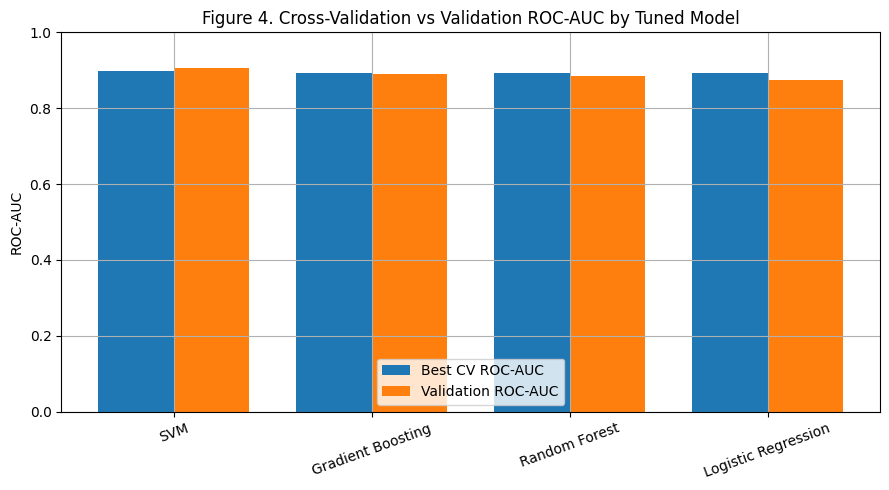

In [15]:
# Figure 4: Hyperparameter tuning and validation ROC-AUC comparison
fig = plt.figure(figsize=(9, 5))
x = np.arange(len(results_df["Model"]))
width = 0.38

plt.bar(x - width/2, results_df["Best CV ROC-AUC"], width=width, label="Best CV ROC-AUC")
plt.bar(x + width/2, results_df["Validation ROC-AUC"], width=width, label="Validation ROC-AUC")

plt.xticks(x, results_df["Model"], rotation=20)
plt.title("Figure 4. Cross-Validation vs Validation ROC-AUC by Tuned Model")
plt.ylabel("ROC-AUC")
plt.ylim(0.0, 1.0)
plt.legend(loc="lower center")
plt.tight_layout()
plt.show()


In [16]:
# Select the deployment model using validation ROC-AUC
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("Deployment model selected from validation set:", best_model_name)
print("Best parameters:", best_params_by_model[best_model_name])
print("Best validation ROC-AUC:", results_df.iloc[0]["Validation ROC-AUC"])

# Evaluate ALL tuned models on the held-out test set for reporting only
test_rows = []

for model_name, model in fitted_models.items():
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]

    test_rows.append({
        "Model": model_name,
        "Test Accuracy": accuracy_score(y_test, y_pred_test),
        "Test Precision": precision_score(y_test, y_pred_test, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred_test, zero_division=0),
        "Test F1": f1_score(y_test, y_pred_test, zero_division=0),
        "Test ROC-AUC": roc_auc_score(y_test, y_prob_test)
    })

test_results_df = pd.DataFrame(test_rows).sort_values(
    by=["Test F1", "Test Accuracy", "Test ROC-AUC"],
    ascending=False
).reset_index(drop=True)

display(test_results_df)

print()
print("Note:")
print("- All tuned models were evaluated on the held-out test set for comparison.")
print(f"- The deployment model remains '{best_model_name}', selected strictly from validation performance.")
print("- Test results are reported for analysis only, not for deployment model selection.")

Deployment model selected from validation set: SVM
Best parameters: {'model__C': 1.0, 'model__class_weight': None, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best validation ROC-AUC: 0.9056844794549713


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.862319,0.870130,0.881579,0.875817,0.900255
1,Random Forest,0.847826,0.866667,0.855263,0.860927,0.892190
2,SVM,0.840580,0.837500,0.881579,0.858974,0.903014
3,Gradient Boosting,0.833333,0.853333,0.842105,0.847682,0.896329



Note:
- All tuned models were evaluated on the held-out test set for comparison.
- The deployment model remains 'SVM', selected strictly from validation performance.
- Test results are reported for analysis only, not for deployment model selection.


In [17]:
# Save selected model test results table for report use
test_results_df.to_csv(RESULTS_CSV_PATH, index=False)
print("Saved selected-model test results to:", RESULTS_CSV_PATH.resolve())

Saved selected-model test results to: C:\Coding\Python\Ucsc\lab\ML\Project\ml_project\notebooks\artifacts\heart_model_results.csv


## 5B. Validation Comparison Figures and Final Test Evaluation

The figures below compare all tuned models on the **validation set**

After selecting the best deployment model from validation performance, the scrip  shows the **single final test-set evaluation** for that selected model only.


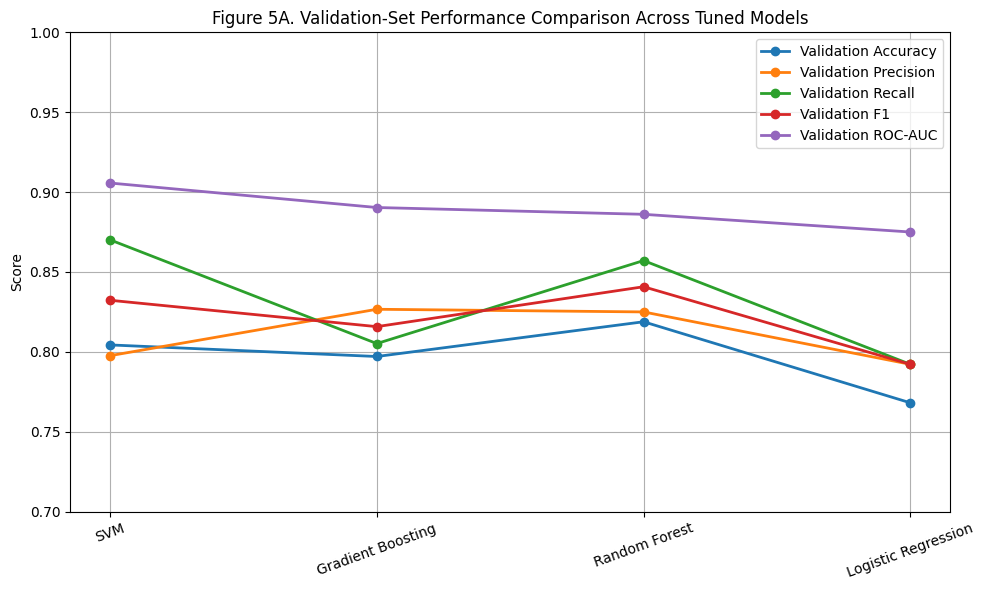

In [18]:
# Figure 5A: Validation-set performance comparison across tuned models
plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Validation Accuracy", "Validation Precision", "Validation Recall", "Validation F1", "Validation ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

fig = plt.figure(figsize=(10, 6))
for metric in plot_df["Metric"].unique():
    subset = plot_df[plot_df["Metric"] == metric]
    plt.plot(subset["Model"], subset["Score"], marker="o", linewidth=2, label=metric)

plt.title("Figure 5A. Validation-Set Performance Comparison Across Tuned Models")
plt.ylabel("Score")
plt.ylim(0.70, 1.00)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()


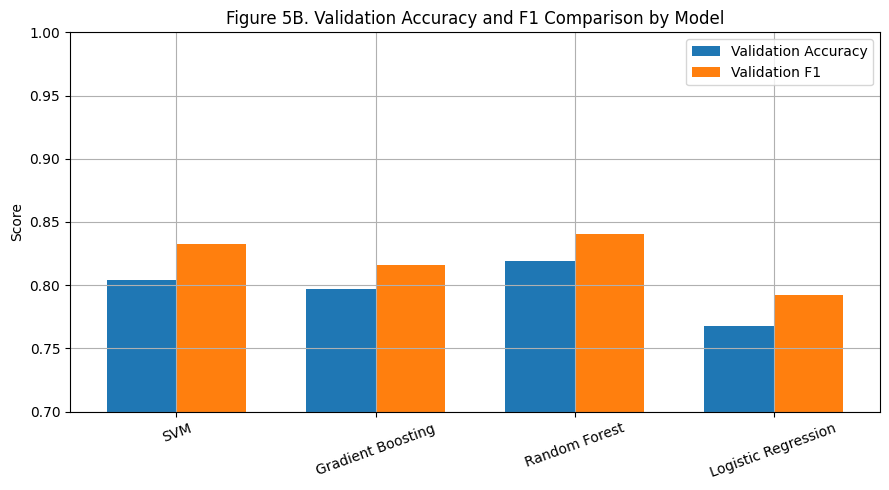

In [19]:
# Figure 5B: Validation accuracy and validation F1 comparison
fig = plt.figure(figsize=(9, 5))
x = np.arange(len(results_df["Model"]))
width = 0.35

plt.bar(x - width/2, results_df["Validation Accuracy"], width=width, label="Validation Accuracy")
plt.bar(x + width/2, results_df["Validation F1"], width=width, label="Validation F1")

plt.xticks(x, results_df["Model"], rotation=20)
plt.ylabel("Score")
plt.ylim(0.70, 1.00)
plt.title("Figure 5B. Validation Accuracy and F1 Comparison by Model")
plt.legend()
plt.tight_layout()
plt.show()


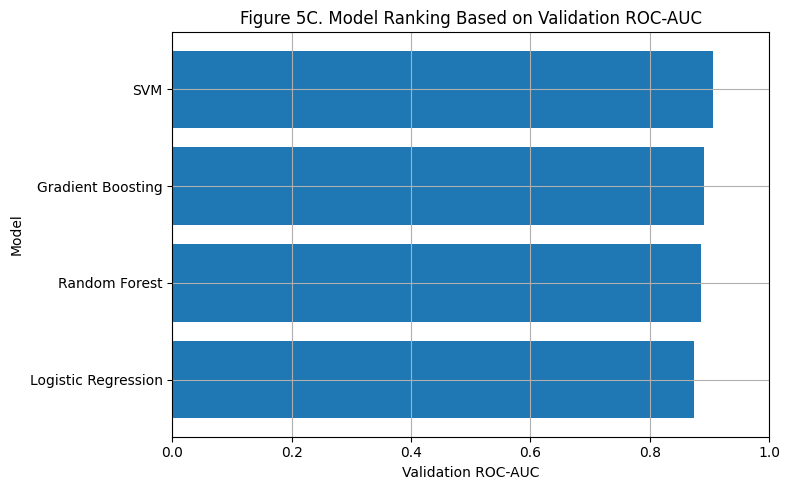

,Model,Best CV ROC-AUC,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,SVM,0.898028,0.804348,0.797619,0.870130,0.832298,0.905684
1,Gradient Boosting,0.891689,0.797101,0.826667,0.805195,0.815789,0.890356
2,Random Forest,0.893429,0.818841,0.825000,0.857143,0.840764,0.886098
3,Logistic Regression,0.892623,0.768116,0.792208,0.792208,0.792208,0.875027


In [20]:
# Figure 5C: Model ranking based on validation ROC-AUC
ranking_df = results_df.sort_values("Validation ROC-AUC", ascending=False).reset_index(drop=True)

fig = plt.figure(figsize=(8, 5))
plt.barh(ranking_df["Model"], ranking_df["Validation ROC-AUC"])
plt.xlabel("Validation ROC-AUC")
plt.ylabel("Model")
plt.xlim(0.0, 1.0)
plt.title("Figure 5C. Model Ranking Based on Validation ROC-AUC")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(ranking_df[[
    "Model",
    "Best CV ROC-AUC",
    "Validation Accuracy",
    "Validation Precision",
    "Validation Recall",
    "Validation F1",
    "Validation ROC-AUC"
]])


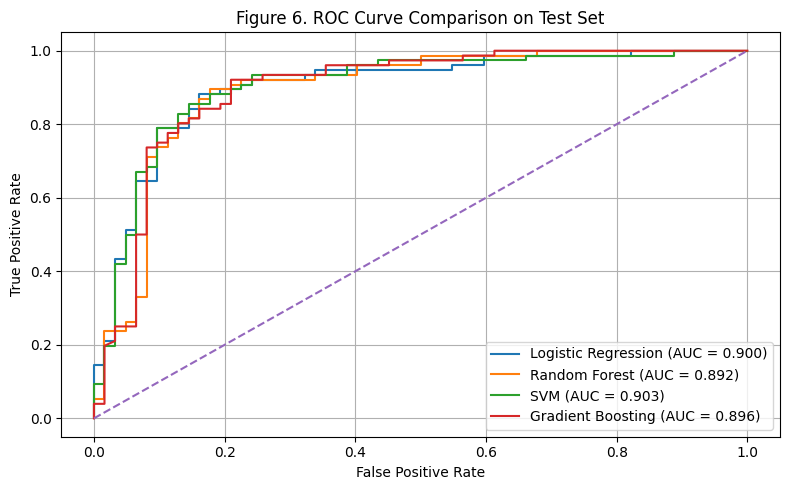

In [21]:
""" # Figure 6: ROC curve on the test set for the selected deployment model
fig = plt.figure()
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
auc_value = roc_auc_score(y_test, y_prob_test)

plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"Figure 6. Test ROC Curve for Selected Deployment Model, {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()
 """

# Figure 6: ROC curve on the test set for the all model
test_probabilities = {}

for model_name, model in fitted_models.items():
    test_probabilities[model_name] = model.predict_proba(X_test)[:, 1]

fig = plt.figure()
for model_name in fitted_models.keys():
    fpr, tpr, _ = roc_curve(y_test, test_probabilities[model_name])
    auc_value = roc_auc_score(y_test, test_probabilities[model_name])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Figure 6. ROC Curve Comparison on Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

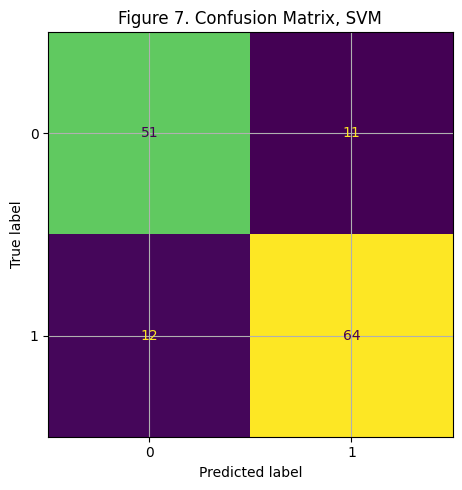

In [22]:
# Figure 7: Confusion matrix for the selected deployment model on the test set
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Figure 7. Confusion Matrix, {best_model_name}")
plt.tight_layout()
plt.show()


## 6. Save the Best Model with `joblib`
This section saves the best fitted pipeline and a compact JSON summary.  
The in-notebook demo app below will **load this saved model** instead of retraining.

In [23]:
summary = {
    "deployment_model_name": best_model_name,
    "deployment_model_params": best_params_by_model[best_model_name],
    "deployment_selection_metric": SELECTION_METRIC,
    "deployment_validation_score": float(results_df.iloc[0]["Validation ROC-AUC"]),
    "dataset_rows": int(len(df)),
    "train_rows": int(len(X_train)),
    "validation_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "validation_results": results_df.to_dict(orient="records"),
    "selected_model_test_result": test_results_df.iloc[0].to_dict()
}

joblib.dump(best_model, MODEL_PATH)
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved deployment model to:", MODEL_PATH.resolve())
print("Saved summary to:", METRICS_PATH.resolve())
print("Deployment model saved without retraining requirement for the dashboard.")


Saved deployment model to: C:\Coding\Python\Ucsc\lab\ML\Project\ml_project\notebooks\artifacts\heart_best_model.joblib
Saved summary to: C:\Coding\Python\Ucsc\lab\ML\Project\ml_project\notebooks\artifacts\heart_model_summary.json
Deployment model saved without retraining requirement for the dashboard.


## 7. In-Notebook Demo App
This is a simple dashboard built with `ipywidgets`.

It **loads the saved deployment model from `artifacts/heart_best_model.joblib`** and performs prediction without retraining.
The saved model is the same model that was:
1. tuned on the training set,
2. selected using validation ROC-AUC,
3. evaluated once on the held-out test set,
4. saved for deployment.


In [24]:
# Load saved model and metadata for the demo app
loaded_model = joblib.load(MODEL_PATH)
with open(METRICS_PATH, "r", encoding="utf-8") as f:
    loaded_summary = json.load(f)

display(Markdown(
    f"**Loaded saved deployment model:** `{loaded_summary['deployment_model_name']}`<br>"
    f"**Deployment selection metric:** `{loaded_summary['deployment_selection_metric']}`<br>"
    f"**Validation ROC-AUC used for selection:** `{loaded_summary['deployment_validation_score']:.3f}`<br>"
    f"**Startup mode:** saved model loaded from disk, no retraining"
))


**Loaded saved deployment model:** `SVM`<br>**Deployment selection metric:** `Validation ROC-AUC`<br>**Validation ROC-AUC used for selection:** `0.906`<br>**Startup mode:** saved model loaded from disk, no retraining

In [25]:
# Dashboard styling
display(HTML("""
<div style="
    background:#f5f7fb;
    border:1px solid #d6dbe4;
    border-radius:16px;
    padding:18px;
    margin:8px 0 16px 0;
">
    <h2 style="margin:0 0 8px 0;">Heart Disease Prediction Demo</h2>
    <p style="margin:0;color:#475569;">
        Enter patient clinical values below, then click <b>Predict</b>.
        This widget uses the already-saved model from <code>artifacts/heart_best_model.joblib</code>.
    </p>
</div>
"""))

In [26]:

# Build the in-notebook dashboard UI
style = {"description_width": "220px"}
layout = widgets.Layout(width="360px")

age = widgets.IntText(value=55, description="Age", style=style, layout=layout)
sex = widgets.Dropdown(options=["Female", "Male"], value="Male", description="Sex", style=style, layout=layout)
cp = widgets.Dropdown(
    options=["typical angina", "atypical angina", "non-anginal", "asymptomatic"],
    value="non-anginal",
    description="Chest pain type",
    style=style,
    layout=layout
)
trestbps = widgets.IntText(value=140, description="Resting blood pressure", style=style, layout=layout)
chol = widgets.IntText(value=240, description="Cholesterol", style=style, layout=layout)
fbs = widgets.Dropdown(options=["False", "True"], value="False", description="Fasting blood sugar >120", style=style, layout=layout)
restecg = widgets.Dropdown(
    options=["normal", "st-t abnormality", "lv hypertrophy"],
    value="normal",
    description="Resting ECG",
    style=style,
    layout=layout
)
thalch = widgets.IntText(value=150, description="Max heart rate", style=style, layout=layout)
exang = widgets.Dropdown(options=["False", "True"], value="False", description="Exercise induced angina", style=style, layout=layout)
oldpeak = widgets.FloatText(value=1.0, description="ST depression (oldpeak)", style=style, layout=layout)
slope = widgets.Dropdown(
    options=["upsloping", "flat", "downsloping"],
    value="flat",
    description="Slope",
    style=style,
    layout=layout
)
ca = widgets.Dropdown(options=[0.0, 1.0, 2.0, 3.0], value=0.0, description="Number of vessels", style=style, layout=layout)
thal = widgets.Dropdown(
    options=["normal", "fixed defect", "reversable defect"],
    value="normal",
    description="Thal",
    style=style,
    layout=layout
)

predict_btn = widgets.Button(description="Predict", button_style="success")
high_risk_btn = widgets.Button(description="Load high-risk sample")
low_risk_btn = widgets.Button(description="Load lower-risk sample")
output = widgets.Output()

def make_input_df():
    return pd.DataFrame([{
        "age": age.value,
        "sex": sex.value,
        "cp": cp.value,
        "trestbps": trestbps.value,
        "chol": chol.value,
        "fbs": fbs.value,
        "restecg": restecg.value,
        "thalch": thalch.value,
        "exang": exang.value,
        "oldpeak": oldpeak.value,
        "slope": slope.value,
        "ca": ca.value,
        "thal": thal.value
    }])

def top_factors(row):
    explanations = []
    r = row.iloc[0].to_dict()
    rules = [
        ("Chest pain type", r["cp"] == "asymptomatic", "asymptomatic chest pain pattern"),
        ("ST depression", r["oldpeak"] >= 1.5, "elevated ST depression"),
        ("Maximum heart rate", r["thalch"] < 120, "lower max heart rate"),
        ("Major vessels", r["ca"] >= 1.0, "major vessel involvement"),
        ("Exercise induced angina", r["exang"] == "True", "exercise induced angina present"),
        ("Cholesterol", r["chol"] >= 240, "elevated cholesterol"),
        ("Resting blood pressure", r["trestbps"] >= 140, "high resting blood pressure"),
        ("Age", r["age"] >= 55, "older age profile")
    ]
    for name, condition, text in rules:
        if condition:
            explanations.append(f"- **{name}**: {text}")
    return explanations[:3] if explanations else ["- **Overall pattern**: values align more closely with a lower-risk profile"]

def on_predict(_):
    row = make_input_df()
    prob = float(loaded_model.predict_proba(row)[0, 1])
    pred = int(prob >= 0.5)
    label = "High Risk of Heart Disease" if pred == 1 else "Lower Risk of Heart Disease"
    recommendation = (
        "Consider physician review and confirmatory cardiovascular assessment."
        if pred == 1 else
        "Continue routine clinical review and interpret this output in the broader clinical context."
    )

    with output:
        clear_output()
        badge_bg = "#fee2e2" if pred == 1 else "#dcfce7"
        badge_fg = "#991b1b" if pred == 1 else "#166534"
        html = f'''
        <div style="background:white;border:1px solid #d6dbe4;border-radius:16px;padding:18px;margin-top:8px;">
            <h3 style="margin:0 0 10px 0;">Prediction Result</h3>
            <div style="display:inline-block;padding:8px 12px;border-radius:999px;background:{badge_bg};color:{badge_fg};font-weight:700;">
                {label}
            </div>
            <p style="margin:14px 0 6px 0;"><b>Risk probability:</b> {prob:.1%}</p>
            <p style="margin:6px 0;"><b>Recommendation:</b> {recommendation}</p>
            <p style="margin:10px 0 6px 0;"><b>Top contributing factors</b></p>
        </div>
        '''
        display(HTML(html))
        factors_html = "<ul style='margin-top:6px;'>" + "".join(
            f"<li>{item.replace('- ', '')}</li>" for item in top_factors(row)
        ) + "</ul>"
        display(HTML(factors_html))

        disclaimer_html = '''
        <div style="
            margin-top:16px;
            padding:12px 14px;
            background:#fff8e1;
            color:#7a4b00;
            border:1px solid #f3d27a;
            border-left:5px solid #f39c12;
            border-radius:8px;
            font-size:14px;
            line-height:1.5;
        ">
            <strong>Disclaimer:</strong> This application is for educational demonstration purposes only and must not be used for clinical diagnosis, treatment, or medical decision-making.
        </div>
        '''
        display(HTML(disclaimer_html))

def load_high_risk(_):
    age.value = 63
    sex.value = "Male"
    cp.value = "asymptomatic"
    trestbps.value = 145
    chol.value = 233
    fbs.value = "True"
    restecg.value = "normal"
    thalch.value = 150
    exang.value = "False"
    oldpeak.value = 2.3
    slope.value = "downsloping"
    ca.value = 0.0
    thal.value = "fixed defect"

def load_low_risk(_):
    age.value = 41
    sex.value = "Female"
    cp.value = "atypical angina"
    trestbps.value = 118
    chol.value = 190
    fbs.value = "False"
    restecg.value = "normal"
    thalch.value = 172
    exang.value = "False"
    oldpeak.value = 0.0
    slope.value = "upsloping"
    ca.value = 0.0
    thal.value = "normal"

predict_btn.on_click(on_predict)
high_risk_btn.on_click(load_high_risk)
low_risk_btn.on_click(load_low_risk)

left_col = widgets.VBox([age, sex, cp, trestbps, chol, fbs, restecg])
right_col = widgets.VBox([thalch, exang, oldpeak, slope, ca, thal])
controls = widgets.HBox([predict_btn, high_risk_btn, low_risk_btn])

display(widgets.HBox([left_col, right_col]))
display(controls)
display(output)


Output()